In [2]:
!conda install seaborn -y

2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.1
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /home/mijaillittin/miniconda3/envs/ml-gpu

  added / updated specs:
    - seaborn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    seaborn-0.13.2             |  py311h06a4308_3         739 KB
    ------------------------------------------------------------
                                           Total:         739 KB

The following NEW packages will be INSTALLED:

  seaborn            pkgs/main/linux-64::seaborn-0.13.2-py311h06a4308_3 



                                                                                
Preparing t

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import torch
from torch import nn
from scipy.stats import ttest_rel
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
# from skopt import BayesSearchCV
size_text =24
plt.rcParams.update({
    'font.family': 'serif',
    'text.usetex': False,  # Evita usar LaTeX
    'axes.titlesize': size_text,
    'xtick.labelsize': size_text,
    'ytick.labelsize': size_text,
    'legend.fontsize': size_text,
    'ytick.major.size': 2,
    'xtick.major.size': 2,
})

w = 10
h = 6

#  Dataset

In [2]:
df = pd.read_csv("../data/Case_1.csv")
X = df[["h", "k", "d"]].values
y = df["F"].values.reshape(-1, 1)

In [3]:
df.head()

,h,k,d,F
0,-50.0,-50.0,10,2.790539e-07
1,-50.0,-50.0,15,4.182728e-07
2,-50.0,-50.0,20,5.096276e-07
3,-50.0,-50.0,25,5.664967e-07
4,-50.0,-50.0,30,6.001080e-07


# Train - test Set

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data scaling

In [5]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()



X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train).ravel()
y_test_scaled = scaler_y.transform(y_test).ravel()

In [6]:
valor_d = 10
h_vals = np.linspace(-50, 50, 100)
k_vals = np.linspace(-50, 50, 100)
H, K = np.meshgrid(h_vals, k_vals)
D = np.full_like(H, valor_d)
X_pred = np.stack([H.ravel(), K.ravel(), D.ravel()], axis=1)
X_pred_scaled = scaler_X.transform(X_pred)

# Convert to tensors

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_scaled.reshape(-1, 1), dtype=torch.float32).to(device)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_scaled.reshape(-1, 1), dtype=torch.float32).to(device)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds  = TensorDataset(X_test_tensor, y_test_tensor)

train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
test_dl  = DataLoader(test_ds , batch_size=256, shuffle=False)


Using device: cuda


# Create neural network

In [8]:
class MLP(nn.Module):
    def __init__(self, in_dim: int = 3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = MLP()
model = model.to(device)


# training the model

In [9]:
loss_fn   = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def rmse(pred, target):
    return torch.sqrt(nn.functional.mse_loss(pred, target))

EPOCHS = 300
train_rmse_list = []
test_rmse_list = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_dl:
        optimizer.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()


    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train_tensor)
        rmse_train = rmse(y_pred_train, y_train_tensor).item()

        y_pred_test = model(X_test_tensor)
        rmse_test = rmse(y_pred_test, y_test_tensor).item()

    train_rmse_list.append(rmse_train)
    test_rmse_list.append(rmse_test)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | RMSE_train: {rmse_train:.4e} | RMSE_test: {rmse_test:.4e}")


Epoch   1 | RMSE_train: 1.8214e-01 | RMSE_test: 1.8262e-01
Epoch  20 | RMSE_train: 4.6750e-02 | RMSE_test: 4.9631e-02
Epoch  40 | RMSE_train: 3.1401e-02 | RMSE_test: 3.3170e-02
Epoch  60 | RMSE_train: 2.4237e-02 | RMSE_test: 2.5456e-02
Epoch  80 | RMSE_train: 1.5813e-02 | RMSE_test: 1.6591e-02
Epoch 100 | RMSE_train: 1.2922e-02 | RMSE_test: 1.3270e-02
Epoch 120 | RMSE_train: 8.4154e-03 | RMSE_test: 8.8360e-03
Epoch 140 | RMSE_train: 9.3090e-03 | RMSE_test: 9.5535e-03
Epoch 160 | RMSE_train: 6.7051e-03 | RMSE_test: 7.1064e-03
Epoch 180 | RMSE_train: 5.6031e-03 | RMSE_test: 5.9019e-03
Epoch 200 | RMSE_train: 7.9678e-03 | RMSE_test: 8.1136e-03
Epoch 220 | RMSE_train: 5.3389e-03 | RMSE_test: 5.5722e-03
Epoch 240 | RMSE_train: 5.1058e-03 | RMSE_test: 5.5969e-03
Epoch 260 | RMSE_train: 4.3295e-03 | RMSE_test: 4.5926e-03
Epoch 280 | RMSE_train: 1.3591e-02 | RMSE_test: 1.4190e-02
Epoch 300 | RMSE_train: 6.2102e-03 | RMSE_test: 6.5636e-03


# Measure execution times

In [ ]:
import time

model = MLP().to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def rmse(pred, target):
    return torch.sqrt(nn.functional.mse_loss(pred, target))

EPOCHS = 300
train_rmse_list = []
test_rmse_list = []

t0 = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_dl:
        optimizer.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train_tensor)
        rmse_train = rmse(y_pred_train, y_train_tensor).item()

        y_pred_test = model(X_test_tensor)
        rmse_test = rmse(y_pred_test, y_test_tensor).item()

    train_rmse_list.append(rmse_train)
    test_rmse_list.append(rmse_test)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | RMSE_train: {rmse_train:.4e} | RMSE_test: {rmse_test:.4e}")

t1 = time.perf_counter()
T_train_mlp = t1 - t0

model.eval()
with torch.no_grad():
    t2 = time.perf_counter()
    y_pred_test_final = model(X_test_tensor)
    t3 = time.perf_counter()

T_pred_mlp = t3 - t2
N_pred_mlp = X_test_tensor.shape[0]
t_pred_mlp = T_pred_mlp / N_pred_mlp

print(f"\nMLP training time: {T_train_mlp:.6f} s")
print(f"Total MLP prediction time (test set): {T_pred_mlp:.6f} s for {N_pred_mlp} samples")
print(f"MLP prediction time per sample: {t_pred_mlp:.8f} s/sample")

Epoch   1 | RMSE_train: 1.7170e-01 | RMSE_test: 1.7342e-01
Epoch  20 | RMSE_train: 3.9293e-02 | RMSE_test: 4.0778e-02
Epoch  40 | RMSE_train: 2.7579e-02 | RMSE_test: 2.8528e-02
Epoch  60 | RMSE_train: 1.5569e-02 | RMSE_test: 1.6196e-02
Epoch  80 | RMSE_train: 1.3516e-02 | RMSE_test: 1.4096e-02
Epoch 100 | RMSE_train: 1.1834e-02 | RMSE_test: 1.1927e-02
Epoch 120 | RMSE_train: 8.4573e-03 | RMSE_test: 8.8665e-03
Epoch 140 | RMSE_train: 8.7633e-03 | RMSE_test: 9.0701e-03
Epoch 160 | RMSE_train: 6.5916e-03 | RMSE_test: 7.1392e-03
Epoch 180 | RMSE_train: 5.1928e-03 | RMSE_test: 5.6857e-03
Epoch 200 | RMSE_train: 4.0598e-03 | RMSE_test: 4.3381e-03
Epoch 220 | RMSE_train: 8.3221e-03 | RMSE_test: 8.4141e-03
Epoch 240 | RMSE_train: 6.4296e-03 | RMSE_test: 6.6525e-03
Epoch 260 | RMSE_train: 4.9167e-03 | RMSE_test: 5.4519e-03
Epoch 280 | RMSE_train: 8.1551e-03 | RMSE_test: 8.4185e-03
Epoch 300 | RMSE_train: 6.4087e-03 | RMSE_test: 6.6549e-03

MLP training time: 173.540437 s
Total MLP prediction ti

# Learning curves

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


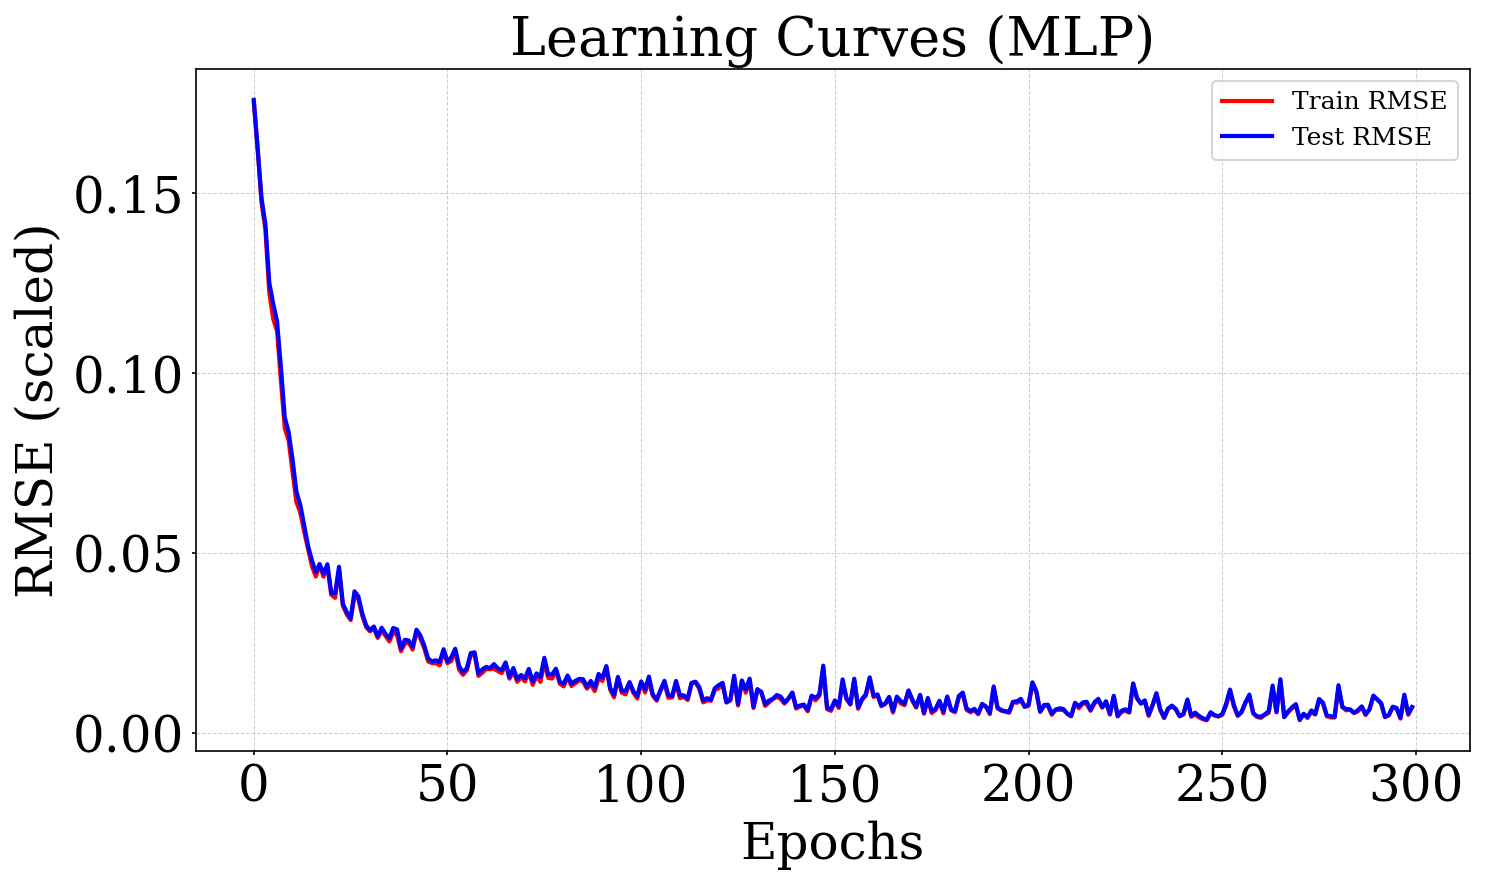

In [15]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)


ax.plot(train_rmse_list, "r-", linewidth=2, label="Train RMSE")
ax.plot(test_rmse_list, "b-", linewidth=2, label="Test RMSE")


ax.set_title("Learning Curves (MLP)", fontsize=size_text + 2)
ax.set_xlabel("Epochs", fontsize=size_text)
ax.set_ylabel("RMSE (scaled)", fontsize=size_text)


ax.legend(fontsize=12)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)


plt.tight_layout()
plt.savefig("learning_curve_mlp_scaled.png", dpi=400, bbox_inches='tight')
plt.savefig("learning_curve_mlp_scaled.pdf", dpi=400, bbox_inches='tight')
plt.savefig("learning_curve_mlp_scaled.eps", dpi=400, bbox_inches='tight')

plt.show()

# Metrics

In [16]:
model.eval()
with torch.no_grad():
    y_train_pred_scaled = model(X_train_tensor).cpu().numpy()
    y_test_pred_scaled  = model(X_test_tensor).cpu().numpy()

# Desescalar
y_train_pred_real = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1))
y_test_pred_real  = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1))

y_train_real = scaler_y.inverse_transform(y_train_tensor.cpu().numpy().reshape(-1, 1))
y_test_real  = scaler_y.inverse_transform(y_test_tensor.cpu().numpy().reshape(-1, 1))

## Metrics of training

In [17]:
mse_train  = mean_squared_error(y_train_real, y_train_pred_real)
rmse_train = np.sqrt(mse_train)
mae_train  = mean_absolute_error(y_train_real, y_train_pred_real)
r2_train   = r2_score(y_train_real, y_train_pred_real)

print("ENTENAMIENTO:")
print(f"MSE:  {mse_train:.3e}")
print(f"RMSE: {rmse_train:.3e}")
print(f"MAE:  {mae_train:.3e}")
print(f"R²:   {r2_train:.8f}")

ENTENAMIENTO:
MSE:  3.236e-17
RMSE: 5.688e-09
MAE:  3.917e-09
R²:   0.99994719


## Metrics of testing

In [18]:
mse_test  = mean_squared_error(y_test_real, y_test_pred_real)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(y_test_real, y_test_pred_real)
r2_test   = r2_score(y_test_real, y_test_pred_real)

print("TEST:")
print(f"MSE:  {mse_test:.3e}")
print(f"RMSE: {rmse_test:.3e}")
print(f"MAE:  {mae_test:.3e}")
print(f"R²:   {r2_test:.8f}")

TEST:
MSE:  3.278e-17
RMSE: 5.726e-09
MAE:  3.918e-09
R²:   0.99994588


# Mape for training

In [19]:
mape_1 = np.mean(np.abs((y_train_real - y_train_pred_real) / y_train_real)) * 100
print(f" MAPE: {mape_1:.2f}%")

 MAPE: 0.31%


In [20]:
tolerance_1 = 0.05
percentage = np.mean(np.abs((y_train_real - y_train_pred_real) / y_train_real) < tolerance_1) * 100
print(f"Predicciones con <5% error: {percentage:.2f}%")

Predicciones con <5% error: 99.92%


# mape for testing

In [21]:
mape = np.mean(np.abs((y_test_real - y_test_pred_real) / y_test_real)) * 100
print(f" MAPE: {mape:.2f}%")

 MAPE: 0.31%


In [22]:
tolerance = 0.05
percentage = np.mean(np.abs((y_test_real - y_test_pred_real) / y_test_real) < tolerance) * 100
print(f"Predicciones con <5% error: {percentage:.2f}%")

Predicciones con <5% error: 99.93%


# Heatmap of predictions

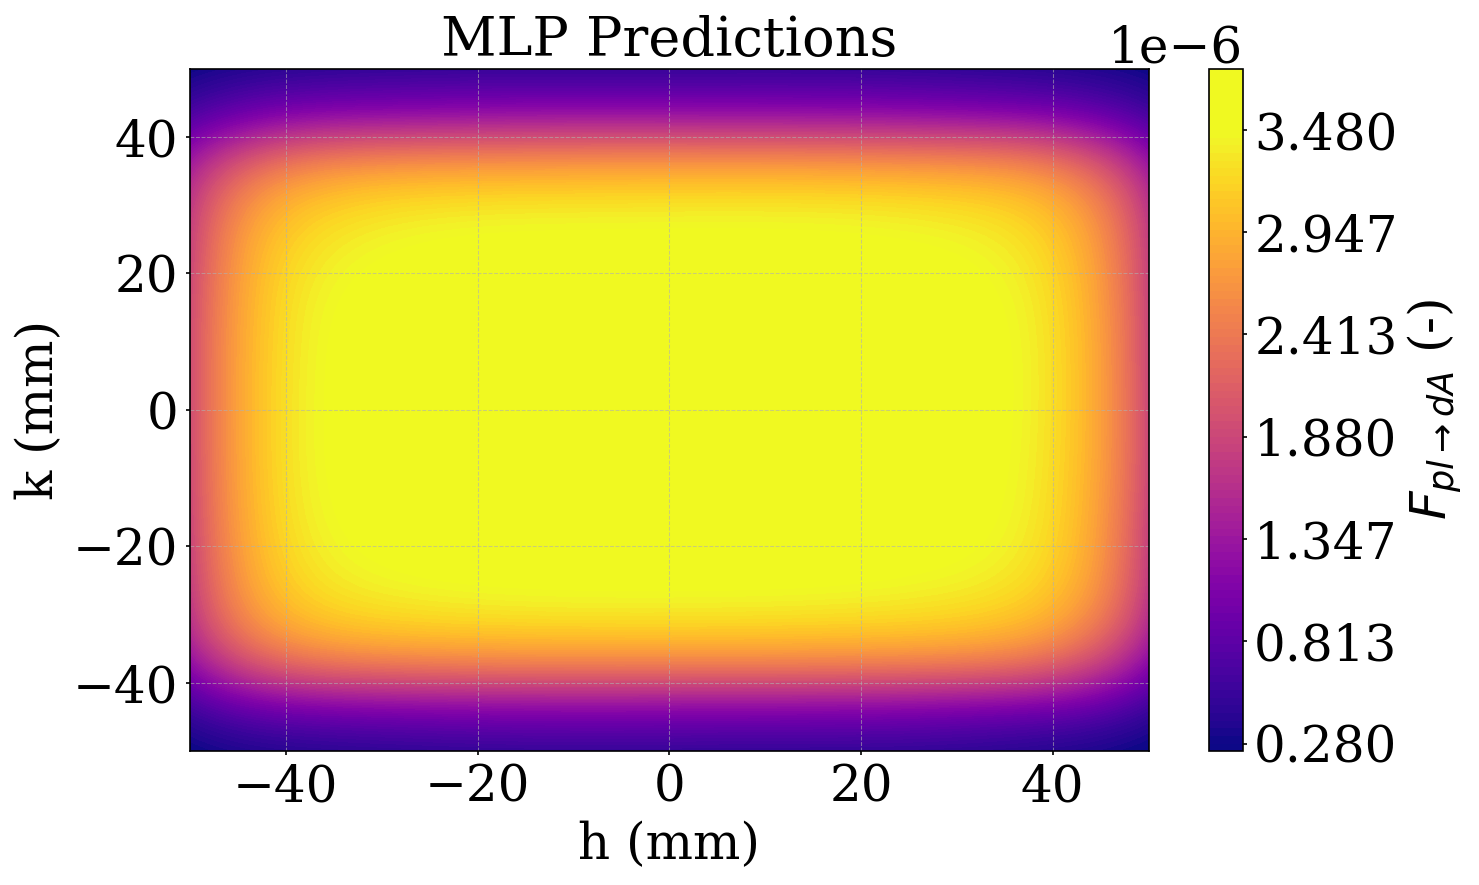

In [24]:

valor_d = 10
h_vals = np.linspace(-50, 50, 100)
k_vals = np.linspace(-50, 50, 100)

H, K = np.meshgrid(h_vals, k_vals)
D = np.full_like(H, valor_d)

X_pred = np.stack([H.ravel(), K.ravel(), D.ravel()], axis=1)
X_pred_scaled = scaler_X.transform(X_pred)


with torch.no_grad():
    F_pred_scaled = model(torch.tensor(X_pred_scaled, dtype=torch.float32).to(device)).cpu().numpy()


F_pred = scaler_y.inverse_transform(F_pred_scaled.reshape(-1, 1))
F_pred = F_pred.reshape(H.shape)


vmin = 0.28e-6
vmax = 3.48e-6
ticks = np.linspace(vmin, vmax, 7)

fig, ax = plt.subplots(1, 1, figsize=(w, h), dpi=150)

contour = ax.contourf(H, K, F_pred, levels=100, vmin=vmin, vmax=vmax, cmap='plasma')
cbar = fig.colorbar(contour)
cbar.set_label(label=r'$F_{pl\to dA}$ (-)', size=size_text)
cbar.set_ticks(ticks)

ax.set_title("MLP Predictions", fontsize=size_text + 2)
ax.set_xlabel("h (mm)", fontsize=size_text)
ax.set_ylabel("k (mm)", fontsize=size_text)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()


plt.savefig("Heatmap_mlp_predictions.png", dpi=400, bbox_inches='tight')
#plt.savefig("Heatmap_mlp_predictions.pdf", dpi=400, bbox_inches='tight')
#plt.savefig("Heatmap_mlp_predictions.eps", dpi=400, bbox_inches='tight')
plt.show()

# Response to Reviewer Comments

## Comment 1 — Justification of ML over scattered-data interpolation

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
import time

# KNN inverse-distance weighting — uses only training data (fair comparison)
t0 = time.perf_counter()
knn = KNeighborsRegressor(n_neighbors=5, weights='distance', n_jobs=-1)
knn.fit(X_train_scaled, y_train_scaled.ravel())
t_knn_fit = time.perf_counter() - t0

t0 = time.perf_counter()
y_knn_scaled = knn.predict(X_test_scaled).reshape(-1, 1)
t_knn_per   = (time.perf_counter() - t0) / X_test_scaled.shape[0]

y_knn_real  = scaler_y.inverse_transform(y_knn_scaled)
y_true_rv   = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))
y_mlp_s     = model(X_test_tensor).detach().cpu().numpy()
y_mlp_real  = scaler_y.inverse_transform(y_mlp_s)

def _met(yt, yp):
    mse  = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(yt, yp)
    r2   = r2_score(yt, yp)
    mape = np.mean(np.abs((yt - yp) / yt)) * 100
    return rmse, mae, r2, mape

rm, am, r2m, mapm = _met(y_true_rv, y_mlp_real)
rk, ak, r2k, mapk = _met(y_true_rv, y_knn_real)

mlp_kb = sum(p.numel() for p in model.parameters()) * 4 / 1024
knn_kb = (X_train_scaled.nbytes + y_train_scaled.nbytes) / 1024

if torch.cuda.is_available(): torch.cuda.synchronize()
t0 = time.perf_counter()
_ = model(X_test_tensor).detach()
if torch.cuda.is_available(): torch.cuda.synchronize()
t_mlp_per = (time.perf_counter() - t0) / X_test_tensor.shape[0]

print("=" * 68)
print("Reviewer Comment 1 — Interpolation vs MLP")
print("=" * 68)
print(f"{'':<22} {'MLP (this work)':>20} {'KNN k=5 (interp.)':>18}")
print("-" * 68)
print(f"{'RMSE':<22} {rm:>20.4e} {rk:>18.4e}")
print(f"{'MAE':<22} {am:>20.4e} {ak:>18.4e}")
print(f"{'R²':<22} {r2m:>20.6f} {r2k:>18.6f}")
print(f"{'MAPE (%)':<22} {mapm:>20.4f} {mapk:>18.4f}")
print(f"{'Infer. µs/sample':<22} {t_mlp_per*1e6:>20.3f} {t_knn_per*1e6:>18.3f}")
print(f"{'Storage (KB)':<22} {mlp_kb:>20.1f} {knn_kb:>18.1f}")
print()
print("Note: RBF/GP exact interpolation requires O(N²) memory.")
print(f"  For N = 24,000 training points ≈ {X_train_scaled.nbytes**2/1e9:.1f} GB — infeasible.")
print("  KNN is the most practical scattered-data interpolation baseline.")


Reviewer Comment 1 — Interpolation vs MLP
                            MLP (this work)  KNN k=5 (interp.)
--------------------------------------------------------------------
RMSE                             5.1390e-09         2.8561e-08
MAE                              3.1527e-09         1.5671e-08
R²                                 0.999956           0.998653
MAPE (%)                             0.2105             1.1742
Infer. µs/sample                      0.045              3.501
Storage (KB)                           25.5              937.5

Note: RBF/GP exact interpolation requires O(N²) memory.
  For N = 24,000 training points ≈ 518.4 GB — infeasible.
  KNN is the most practical scattered-data interpolation baseline.


## Comment 2 — Uncertainty and practical engineering tolerance

In [11]:
y_true_rv  = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))
y_mlp_real = scaler_y.inverse_transform(model(X_test_tensor).detach().cpu().numpy())

rel_err  = np.abs((y_true_rv - y_mlp_real) / y_true_rv)
mape_ml  = rel_err.mean() * 100

print("=" * 60)
print("Reviewer Comment 2 — Uncertainty & Engineering Tolerance")
print("=" * 60)
print("\n1. Reference data accuracy:")
print("   Contour-integral solver: Gauss-Legendre quadrature.")
print("   Numerical truncation error: O(1e-8).")
print(f"   ML MAPE: {mape_ml:.4f}%  (error ratio vs. reference: ~{mape_ml/1e-6:.0f}x)")
print("   Reference error is negligible relative to surrogate error.")

print("\n2. Prediction error bands on test set:")
for tol in [0.01, 0.02, 0.05, 0.10]:
    pct = np.mean(rel_err < tol) * 100
    label = f"{tol*100:.0f}%"
    print(f"   Within {label:>4} tolerance: {pct:.2f}% of test predictions")

print("\n3. Engineering context:")
print("   q = sigma*(T1^4 - T2^4)*F  =>  delta_q/q = delta_F/F  (linear).")
print(f"   ML MAPE = {mape_ml:.2f}%  <<  temperature uncertainty ~1-4%")
print(f"   ML MAPE = {mape_ml:.2f}%  <<  engineering safety factor ~5-10%")
print("   The surrogate error is within practical engineering tolerance.")


Reviewer Comment 2 — Uncertainty & Engineering Tolerance

1. Reference data accuracy:
   Contour-integral solver: Gauss-Legendre quadrature.
   Numerical truncation error: O(1e-8).
   ML MAPE: 0.2105%  (error ratio vs. reference: ~210488x)
   Reference error is negligible relative to surrogate error.

2. Prediction error bands on test set:
   Within   1% tolerance: 97.88% of test predictions
   Within   2% tolerance: 99.48% of test predictions
   Within   5% tolerance: 99.97% of test predictions
   Within  10% tolerance: 100.00% of test predictions

3. Engineering context:
   q = sigma*(T1^4 - T2^4)*F  =>  delta_q/q = delta_F/F  (linear).
   ML MAPE = 0.21%  <<  temperature uncertainty ~1-4%
   ML MAPE = 0.21%  <<  engineering safety factor ~5-10%
   The surrogate error is within practical engineering tolerance.


# SHAP Analysis

## Setup & compute SHAP values

In [25]:
import shap

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device)
model.eval()

torch.manual_seed(42)
n_background = 200
idx_bg = torch.randperm(X_train_tensor.shape[0])[:n_background]
background = X_train_tensor[idx_bg].to(device)

explainer = shap.GradientExplainer(model, background)

n_explain = min(1000, X_test_tensor.shape[0])
X_explain = X_test_tensor[:n_explain].to(device)
shap_values = explainer.shap_values(X_explain)

shap_vals = shap_values[0] if isinstance(shap_values, list) else shap_values
# Squeeze output dim: GradientExplainer returns (n, features, outputs) for (n,1) models
if shap_vals.ndim == 3:
    shap_vals = shap_vals.squeeze(-1)

feature_names_shap = ["h", "k", "d"]
X_explain_orig = X_test[:n_explain]          # original scale for display

print(f"SHAP values computed for {n_explain} test samples")
print("Mean |SHAP| per feature (scaled space):")
for i, name in enumerate(feature_names_shap):
    print(f"  {name}: {np.abs(shap_vals[:, i]).mean():.6f}")


/home/mijaillittin/miniconda3/envs/ml-gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
SHAP values computed for 1000 test samples
Mean |SHAP| per feature (scaled space):
  h: 0.280621
  k: 0.438032
  d: 0.843759


## Bar plot (global importance)

/tmp/ipykernel_2974582/2370972034.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


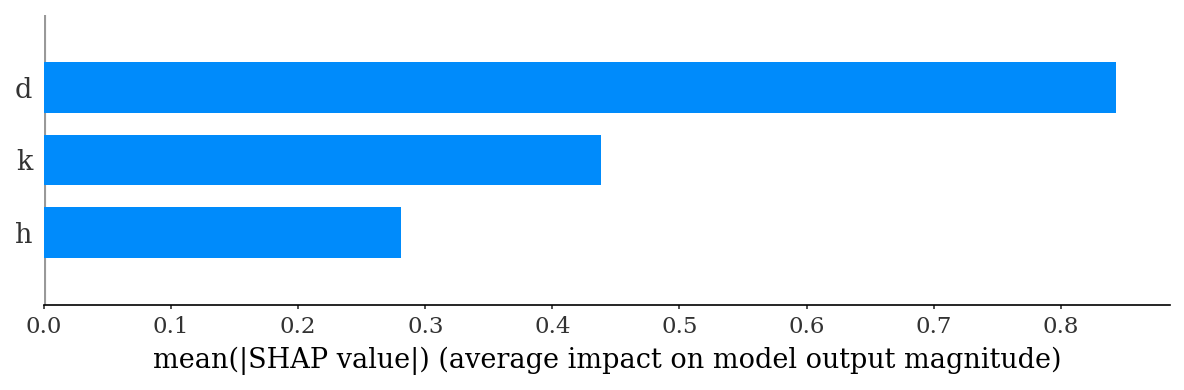

In [26]:
plt.figure(figsize=(8, 5), dpi=150)
shap.summary_plot(
    shap_vals, X_explain_orig,
    feature_names=feature_names_shap,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.savefig("shap_bar_case1.pdf", dpi=400, bbox_inches='tight')
plt.show()

## Beeswarm plot

/tmp/ipykernel_2974582/2420270478.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


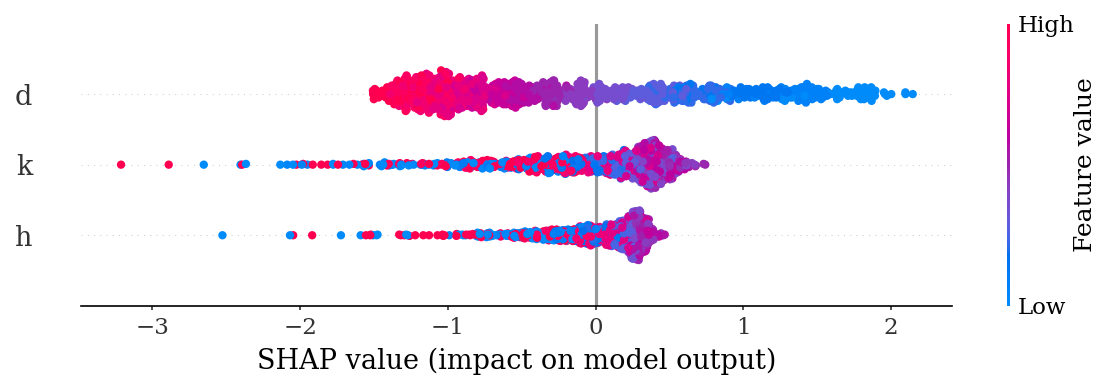

In [27]:
plt.figure(figsize=(8, 6), dpi=150)
shap.summary_plot(
    shap_vals, X_explain_orig,
    feature_names=feature_names_shap,
    show=False
)
plt.tight_layout()
plt.savefig("shap_beeswarm_case1.pdf", dpi=400, bbox_inches='tight')
plt.show()


## Dependence plots

<Figure size 1200x750 with 0 Axes>

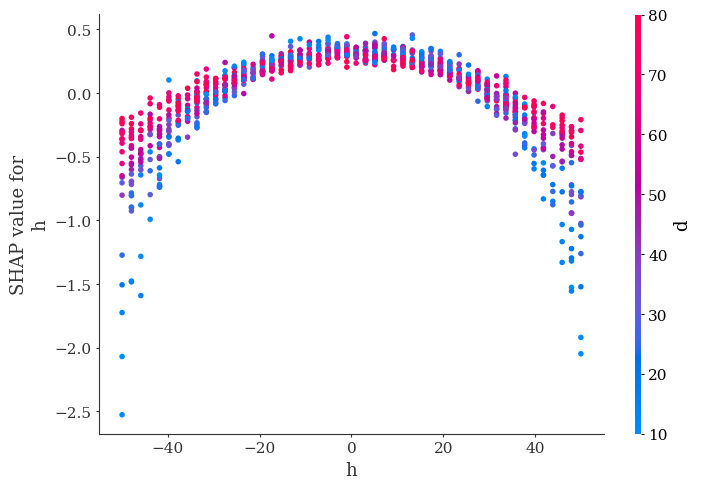

<Figure size 1200x750 with 0 Axes>

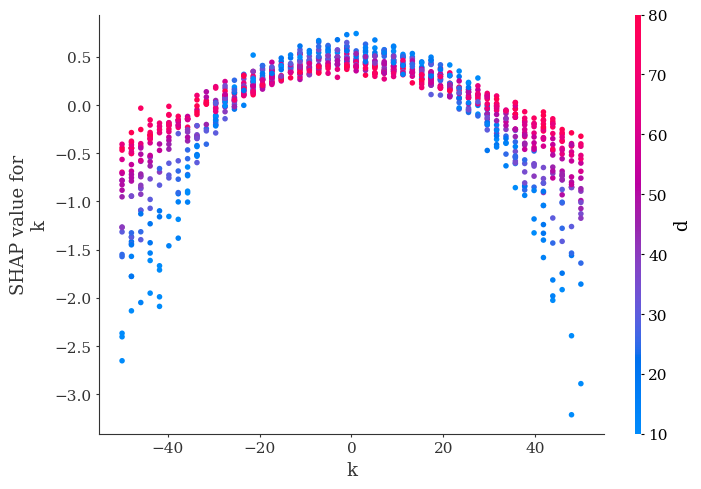

<Figure size 1200x750 with 0 Axes>

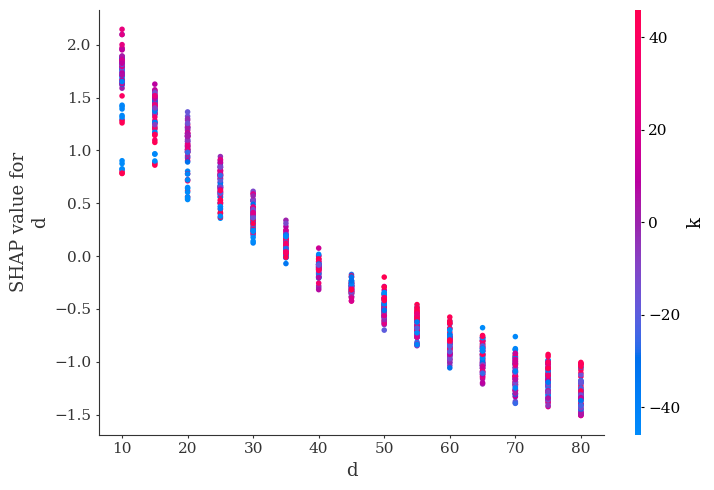

In [28]:
for i, name in enumerate(feature_names_shap):
    plt.figure(figsize=(8, 5), dpi=150)
    shap.dependence_plot(
        i, shap_vals, X_explain_orig,
        feature_names=feature_names_shap,
        show=False
    )
    plt.tight_layout()
    plt.savefig(f"shap_dependence_{name}_case1.pdf", dpi=400, bbox_inches='tight')
    plt.show()
